In [2]:
import cajal.sample_swc
import cajal.swc


In [3]:
#dist matrix with only metadata SWCs
cajal.sample_swc.compute_icdm_all_euclidean(
    infolder = "/home/njay/cajal/Data/BothGouwen_data/Both_mouse_swc",
    out_csv="../data/processed/noaxons_both_mouse_100pts_euclidean_icdm.csv",
    preprocess=cajal.swc.preprocessor_eu(
        structure_ids=[1,3,4],
        soma_component_only=False),
    n_sample=100,
    num_processes=8)  # num_processes can be set to the number of cores on your machine


100%|████████████████████████████████████████████████████████████████████████████████▊| 584/585 [02:17<00:00,  4.26it/s]


[]

In [4]:
import cajal.run_gw

cajal.run_gw.compute_gw_distance_matrix(
    "../data/processed/noaxons_both_mouse_100pts_euclidean_icdm.csv",
    "../data/processed/noaxons_both_mouse_100pts_euclidean_GW_dmat.csv",
    num_processes=8)


  0%|          | 0/170820 [00:00<?, ?it/s]

(array([[ 0.        , 19.24118091, 16.37523121, ..., 31.04310762,
         45.53733946, 24.51622228],
        [19.24118091,  0.        , 15.74872567, ..., 14.28600489,
         50.34176544, 19.2878446 ],
        [16.37523121, 15.74872567,  0.        , ..., 24.14337713,
         49.27847556, 18.79152571],
        ...,
        [31.04310762, 14.28600489, 24.14337713, ...,  0.        ,
         53.24723197, 15.63117862],
        [45.53733946, 50.34176544, 49.27847556, ..., 53.24723197,
          0.        , 53.14227655],
        [24.51622228, 19.2878446 , 18.79152571, ..., 15.63117862,
         53.14227655,  0.        ]]),
 None)

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1857: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



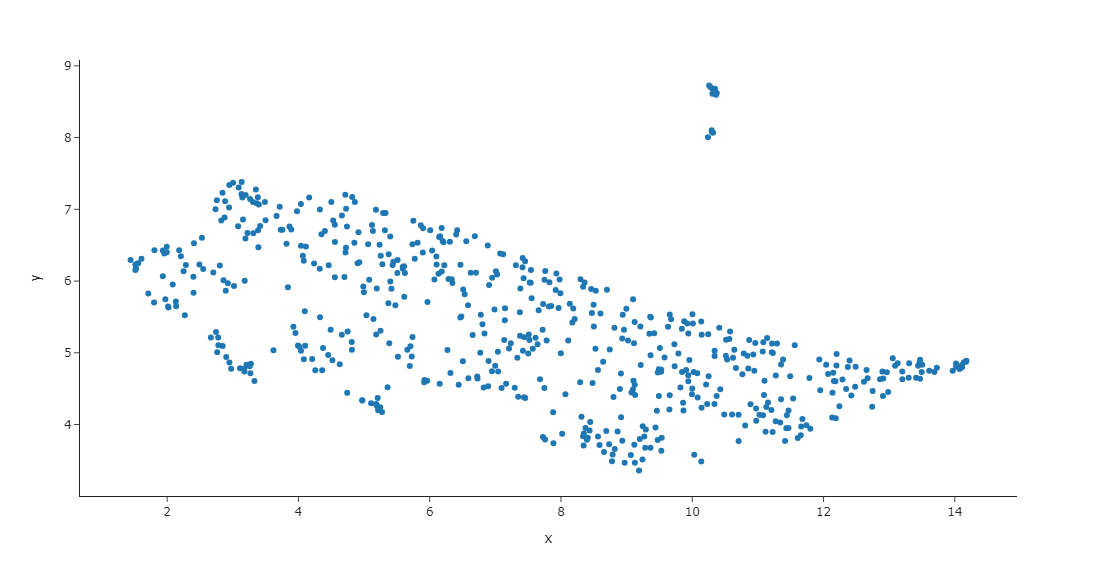

In [7]:
import plotly.io as pio
import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/noaxons_both_mouse_100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)
# Visualize UMAP with specified width and height
fig = plotly.express.scatter(x=embedding[:, 0],
                             y=embedding[:, 1],
                             template="simple_white",
                             hover_name=[m + ".swc" for m in cells])

# Update layout with width and height
width_inches = 8
height_inches = 6
fig.update_layout(
    width=width_inches * 96,  # 96 pixels per inch
    height=height_inches * 96,  # 96 pixels per inch
)
fig.show()


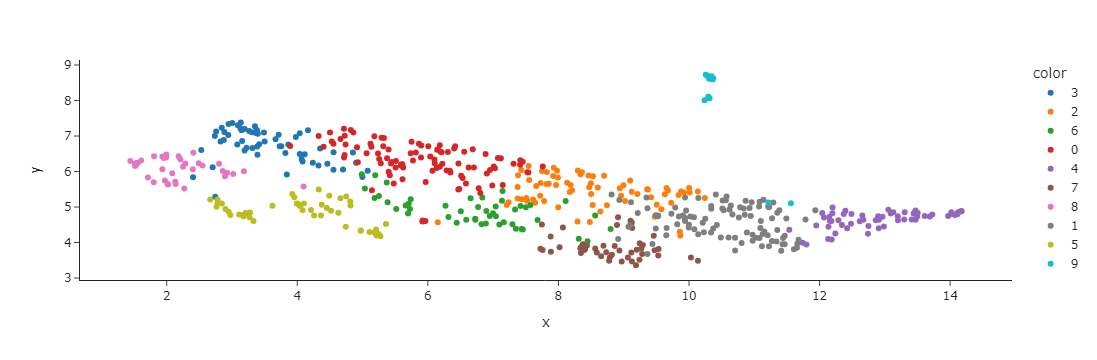

In [8]:
#Leiden clustering UMAP
clusters = cajal.utilities.leiden_clustering(gw_dist, seed=1)
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells],
                       color = [str(m) for m in clusters])

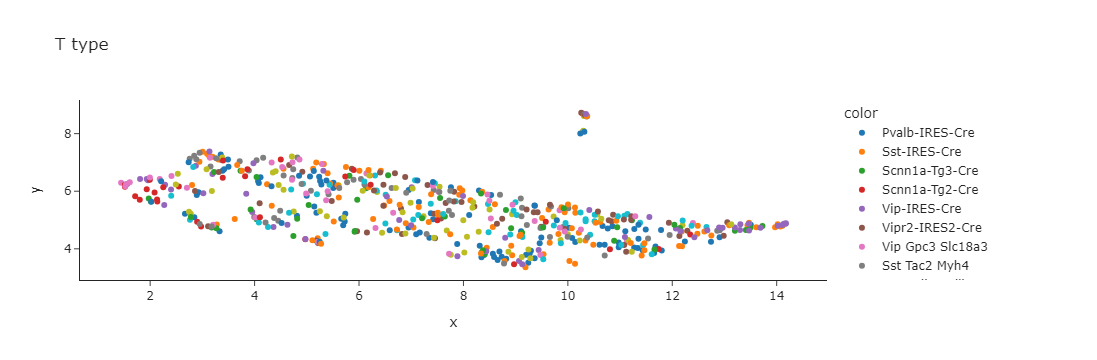

In [11]:
import pandas
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]

metadata = pandas.read_csv("../data/raw/Cajal_BothGouwens_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells_without_suffix],
                       color = metadata["T type"], title = "T type"
                      )

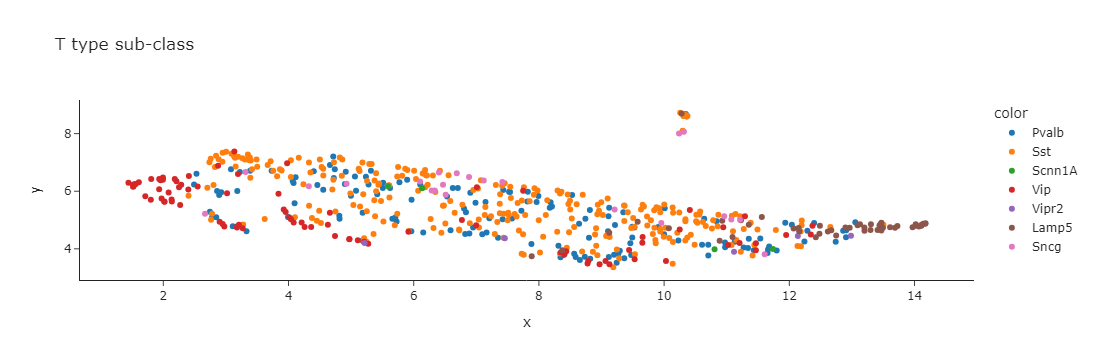

In [16]:
import pandas

plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells_without_suffix],
                       color = metadata["T type sub-class"], title = "T type sub-class"
                      )

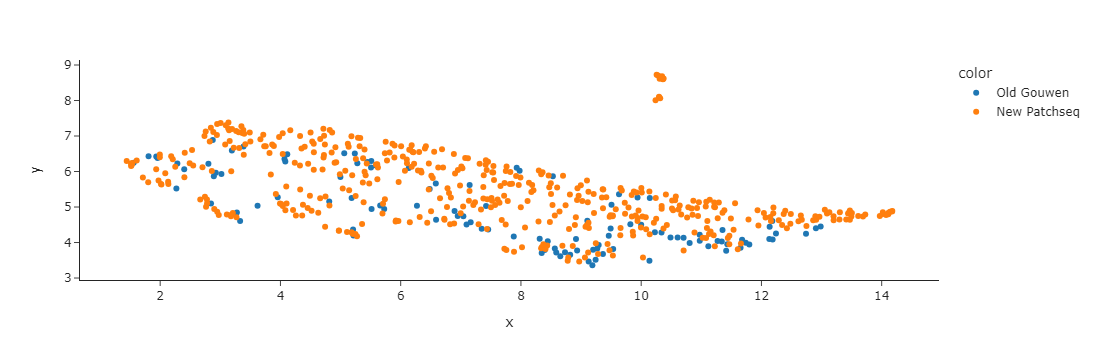

In [18]:
import pandas
plotly.express.scatter(
        x=embedding[:, 0],
        y=embedding[:, 1],
        template="simple_white",
        hover_name=[m + ".swc" for m in cells_without_suffix],
        color=metadata["Dataset"]
)

In [19]:
import cajal.laplacian_score
import numpy
import pandas
from scipy.spatial.distance import squareform

# Build indicator matrix
layers = numpy.unique(metadata["T type sub-class"])
indicator = (numpy.array(metadata["T type sub-class"])[:,None] == layers)*1

# Compute the Laplacian score
laplacian = pandas.DataFrame(cajal.laplacian_score.laplacian_scores(indicator,
                                       gw_dist,
                                       numpy.median(squareform(gw_dist)),
                                       permutations = 5000,
                                       covariates = None,
                                       return_random_laplacians = False)[0])
laplacian.index = layers

print(laplacian)

        feature_laplacians  laplacian_p_values  laplacian_q_values
Lamp5             0.896662            0.000200            0.000700
Pvalb             0.997904            0.022595            0.039542
Scnn1A            1.004405            0.961208            0.961208
Sncg              1.003533            0.843231            0.983770
Sst               0.982157            0.000200            0.000700
Vip               0.969005            0.000200            0.000700
Vipr2             1.001981            0.432314            0.605239


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sub-class"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)
numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 4 members, which is less than n_splits=5.



0.5948717948717949

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cell_type = numpy.array(metadata["T type sentencecase"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


NameError: name 'numpy' is not defined

0.6023872679045092


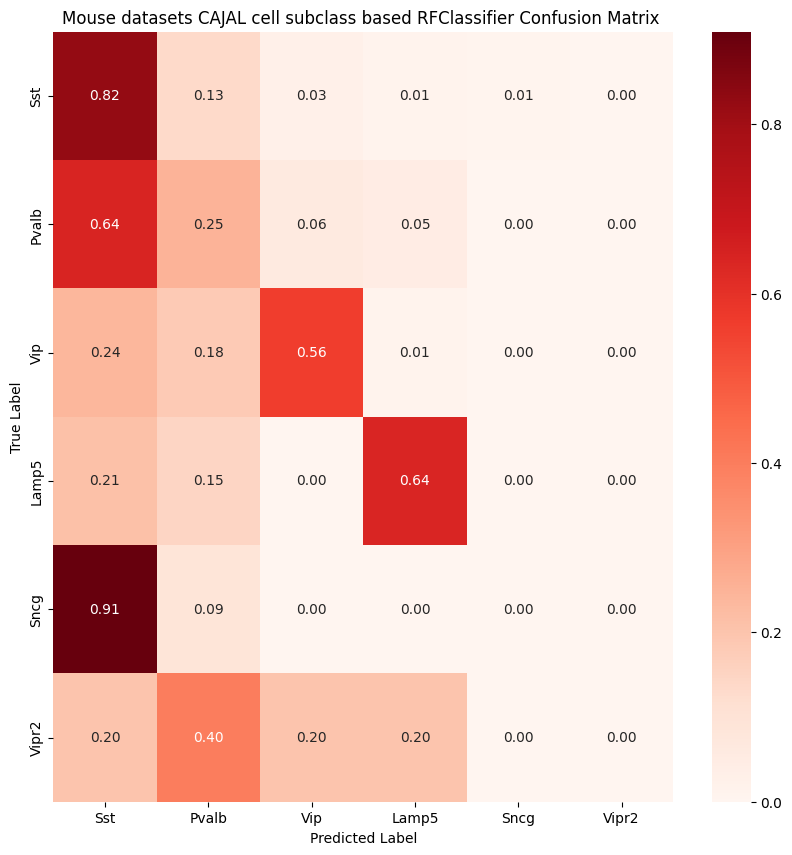

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cell_type = np.array(metadata["T type sub-class"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index

# Filter the metadata and feature matrix based on selected classes
class_indices = metadata["T type sub-class"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy = np.mean(accuracy)
print(mean_accuracy)  # Print the mean accuracy
predictions = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

# Create a confusion matrix
conf_mat = confusion_matrix(cell_type[class_indices], predictions, labels=selected_classes)
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis]
conf_mat_df = pd.DataFrame(conf_mat_percentage, index=selected_classes, columns=selected_classes)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat_df, annot=True, cmap="Reds", fmt='.2f')
plt.title("Mouse datasets CAJAL cell subclass based RFClassifier Confusion Matrix ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
#plt.savefig("mouse datasets.png")
plt.show()


0.4548168498168498


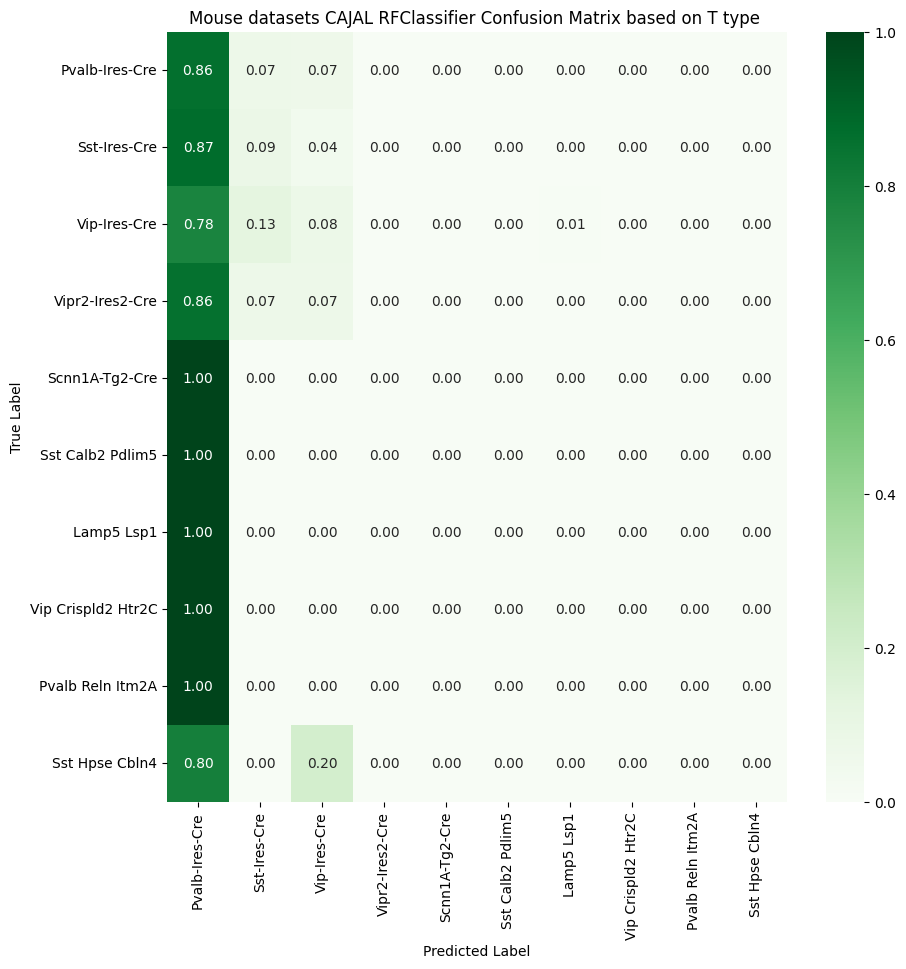

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cell_type = np.array(metadata["T type sentencecase"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index

# Filter the metadata and feature matrix based on selected classes
class_indices = metadata["T type sentencecase"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy = np.mean(accuracy)
print(mean_accuracy)  

predictions = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

# Create a confusion matrix
conf_mat = confusion_matrix(cell_type[class_indices], predictions, labels=selected_classes)
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis]
conf_mat_df = pd.DataFrame(conf_mat_percentage, index=selected_classes, columns=selected_classes)

# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat_df, annot=True, cmap="Greens", fmt=".2f")
plt.title("Mouse datasets CAJAL RFClassifier Confusion Matrix based on T type ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
